In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

filtering train.csv down to building 105, meter 0 (electricity) only.


In [2]:
train = pd.read_csv('../data/train.csv')
train = train[train["building_id"] == 105]
train.reset_index()

,index,building_id,meter,timestamp,meter_reading
0,103,105,0,2016-01-01 00:00:00,23.3036
1,2404,105,0,2016-01-01 01:00:00,45.6071
2,4697,105,0,2016-01-01 02:00:00,45.6071
3,6996,105,0,2016-01-01 03:00:00,45.1071
4,9292,105,0,2016-01-01 04:00:00,45.6071
...,...,...,...,...,...
8779,20204402,105,0,2016-12-31 19:00:00,46.9685
8780,20206765,105,0,2016-12-31 20:00:00,45.5470
8781,20209131,105,0,2016-12-31 21:00:00,45.8750
8782,20211496,105,0,2016-12-31 22:00:00,45.4375


In [3]:
train.drop(columns=["meter","building_id"], inplace = True)
train.head()

,timestamp,meter_reading
103,2016-01-01 00:00:00,23.3036
2404,2016-01-01 01:00:00,45.6071
4697,2016-01-01 02:00:00,45.6071
6996,2016-01-01 03:00:00,45.1071
9292,2016-01-01 04:00:00,45.6071


In [4]:
train.describe()

,meter_reading
count,8784.000000
mean,78.124031
std,27.533489
min,23.303600
25%,56.299725
50%,75.115100
75%,86.464750
max,173.945000


In [5]:
train.info()

<class 'pandas.DataFrame'>
Index: 8784 entries, 103 to 20213862
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      8784 non-null   str    
 1   meter_reading  8784 non-null   float64
dtypes: float64(1), str(1)
memory usage: 205.9 KB


hour-of-day average, extract hour from timestamp and average across all days.


<Axes: xlabel='hour'>

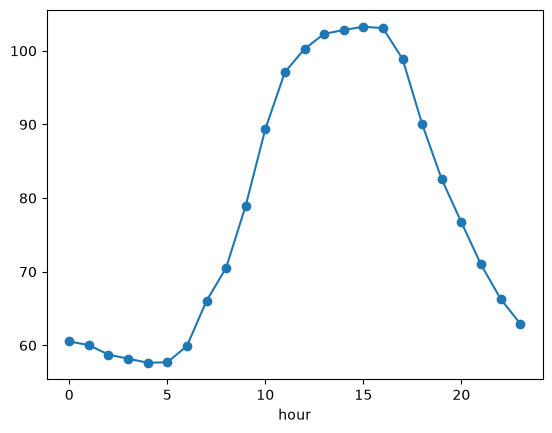

In [6]:
train["timestamp"] = pd.to_datetime(train["timestamp"])
train["hour"] = train["timestamp"].dt.hour
plt.grid()
train.groupby('hour')['meter_reading'].mean().plot(kind='line', marker='o')

clear daily cycle. flat and low overnight (~58 kWh between 2-5am), starts climbing at 6am, peaks 12pm-4pm (~100-103 kWh), tapers off through the evening. makes sense for an occupancy-driven load - lighting, HVAC, classroom/lab equipment ramping up with the school day.


day-of-week average (0=Mon...6=Sun).


<Axes: xlabel='dow'>

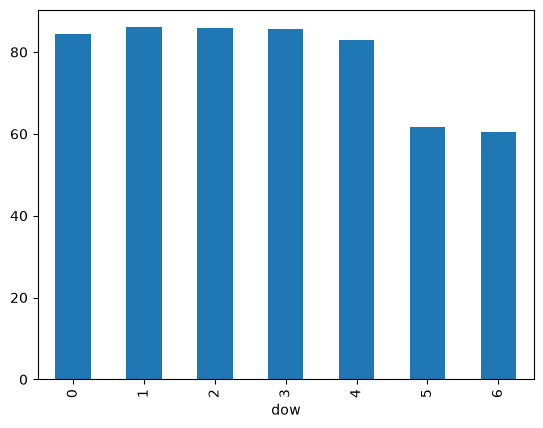

In [7]:
train['dow'] = train['timestamp'].dt.dayofweek  # 0=Mon
train.groupby('dow')['meter_reading'].mean().plot(kind='bar')

weekdays average ~83-86 kWh, weekends drop to ~61-62 kWh, about 28% lower. drop is real but not extreme - some baseload (HVAC setback, servers, security) keeps running even when building isn't active.


top 10 highest readings of the year

In [8]:
train.sort_values('meter_reading', ascending=False).head(10)

,timestamp,meter_reading,hour,dow
18406738,2016-11-29 13:00:00,173.945,13,1
18409099,2016-11-29 14:00:00,172.031,14,1
18413822,2016-11-29 16:00:00,171.601,16,1
18411461,2016-11-29 15:00:00,171.351,15,1
18404377,2016-11-29 12:00:00,169.664,12,1
18352459,2016-11-28 14:00:00,168.969,14,0
18402018,2016-11-29 11:00:00,168.141,11,1
17953473,2016-11-21 13:00:00,168.047,13,0
18350097,2016-11-28 13:00:00,167.797,13,0
18347735,2016-11-28 12:00:00,165.453,12,0


6 of the top 10 are all from the same Nov 28-29 window


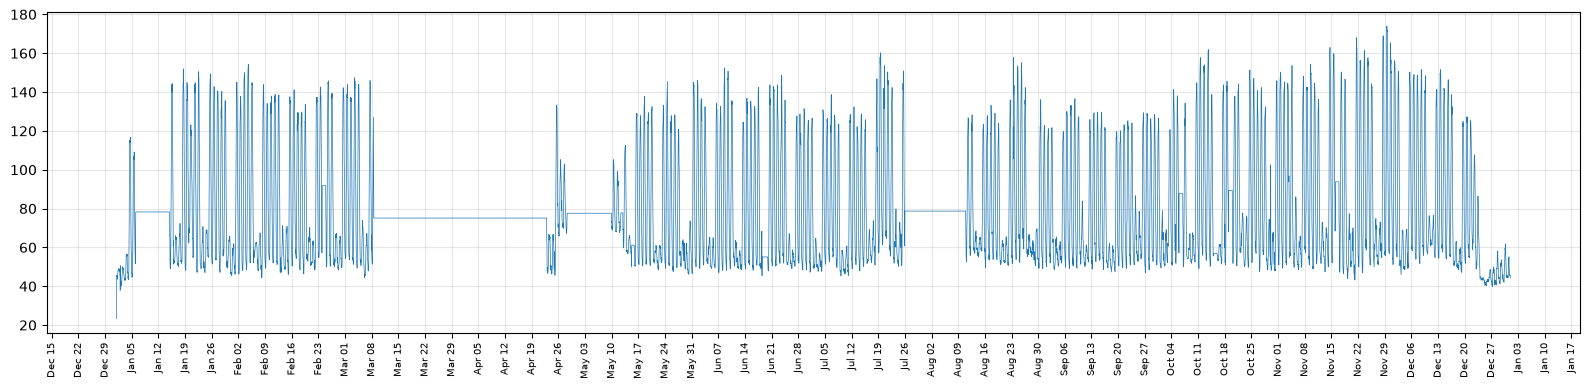

In [18]:
fig, ax = plt.subplots(figsize=(16,4))
ax.plot(train['timestamp'], train['meter_reading'], linewidth=0.5)
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.xticks(rotation=90, fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### hour x weekday heatmap
combining the daily and weekly views into one picture

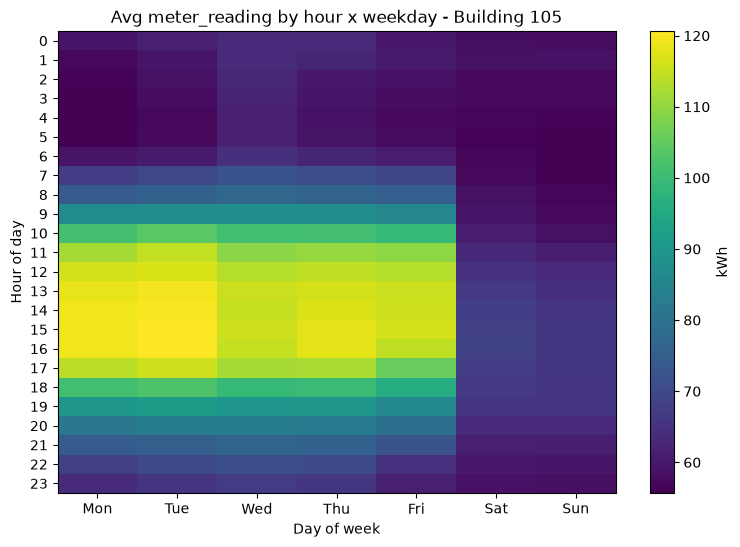

In [10]:
pivot = train.pivot_table(index='hour', columns='dow', values='meter_reading', aggfunc='mean')
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(9,6))
im = ax.imshow(pivot, aspect='auto', cmap='viridis')
ax.set_yticks(range(24)); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(7)); ax.set_xticklabels(pivot.columns)
ax.set_xlabel('Day of week'); ax.set_ylabel('Hour of day')
ax.set_title('Avg meter_reading by hour x weekday - Building 105')
plt.colorbar(im, label='kWh')
plt.show()

### weekday vs weekend load profile
same info as the heatmap, just easier to read exact numbers off.


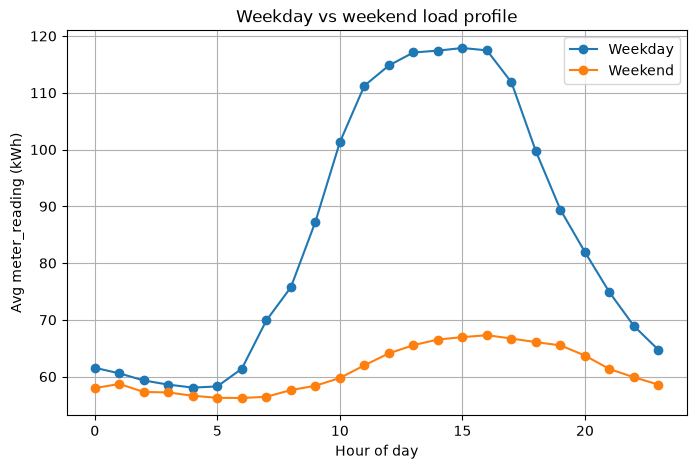

In [11]:
train['is_weekend'] = train['dow'] >= 5

fig, ax = plt.subplots(figsize=(8,5))
for is_we, grp in train.groupby('is_weekend'):
    label = 'Weekend' if is_we else 'Weekday'
    grp.groupby('hour')['meter_reading'].mean().plot(ax=ax, marker='o', label=label)
ax.set_xlabel('Hour of day'); ax.set_ylabel('Avg meter_reading (kWh)')
ax.set_title('Weekday vs weekend load profile')
ax.legend(); ax.grid()
plt.show()

### distribution shape


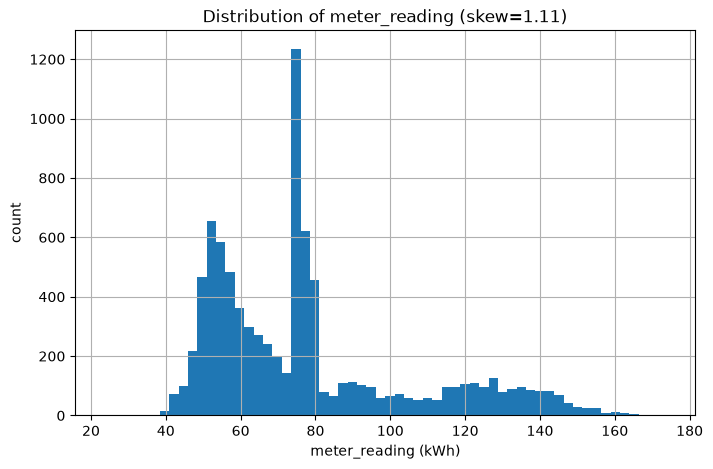

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
train['meter_reading'].hist(bins=60, ax=ax)
ax.set_xlabel('meter_reading (kWh)'); ax.set_ylabel('count')
ax.set_title(f"Distribution of meter_reading (skew={train['meter_reading'].skew():.2f})")
plt.show()

few clusters here instead of one smooth peak - low ~45-60 kWh (nights/weekends), a spike right at 75 (the flat/bad data stretch), and spread 90-160 (occupied daytime).


### autocorrelation (ACF)

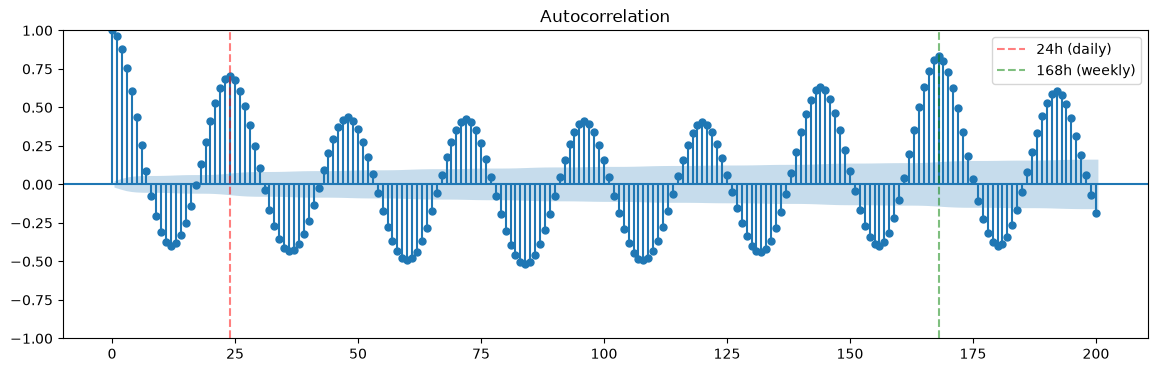

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14,4))
plot_acf(train.set_index('timestamp')['meter_reading'], lags=200, ax=ax)
ax.axvline(24, color='red', linestyle='--', alpha=0.5, label='24h (daily)')
ax.axvline(168, color='green', linestyle='--', alpha=0.5, label='168h (weekly)')
ax.legend()
plt.show()

clear peaks at every 24-hour lag (correlation ~0.4-0.7), confirms the daily cycle is strong all year 
lag-168 (1 week) peak is noticeably taller (~0.7) than the daily peaks around it (~0.4) - meaning same hour same day-of-week last week predicts today better than a random day last week does